In [2]:
# # Gõ dòng này vào cell đầu tiên và bấm Run (Shift + Enter)
# get_ipython().run_line_magic('run', '../_setup.py')

In [3]:
from functools import partial
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox
from utilsforecast.evaluation import evaluate
from utilsforecast.feature_engineering import pipeline, trend
from utilsforecast.losses import rmse, mae, mape as _mape, mase, quantile_loss, mqloss
from statsforecast import StatsForecast
from statsforecast.models import (
    HistoricAverage,
    Naive,
    RandomWalkWithDrift,
    SeasonalNaive,
    SklearnModel,
)
from fpppy.models import LinearRegression

def mape(df, models, id_col = "unique_id", target_col = "y"):
    df_mape = _mape(df, models, id_col=id_col, target_col=target_col)
    df_mape.loc[:, df_mape.select_dtypes(include="number").columns] *= 100
    return df_mape

def quantile_score(df, models, q=0.5, id_col="unique_id", target_col="y"):
    df_qs = quantile_loss(df, models, q=q, id_col=id_col, target_col=target_col)
    df_qs.loc[:, df_qs.select_dtypes(include="number").columns] *= 2
    return df_qs

def plot_diagnostics(data):
    _, axes = plt.subplot_mosaic([["resid", "resid"], ["acf", "hist"]])
    ax = axes["resid"]
    ax.plot(data["ds"], data["resid"])
    ax.set(title="Innovation Residuals")
    ax = axes["acf"]
    plot_acf(data["resid"].dropna(),
        zero=False, bartlett_confint=False, auto_ylims=True, ax=ax)
    ax.set(title="ACF Plot", xlabel="lag[1]", ylabel="acf")
    ax = axes["hist"]
    ax.hist(data["resid"], bins=20)
    ax.set(title="Histogram", xlabel="resid", ylabel="count")


In [4]:
BASE_DIR = Path.cwd().parent.parent
DATA_DIR = BASE_DIR / "data"
print(DATA_DIR)

d:\Documents\GitHub\-Time-Series-Analysis-and-Forecasting-methods-\data


# Chapter 5  The forecaster’s toolbox

In this chapter, we discuss some general tools that are useful for many different forecasting situations. We will describe some benchmark forecasting methods, procedures for checking whether a forecasting method has adequately utilised the available information, techniques for computing prediction intervals, and methods for evaluating forecast accuracy.

Each of the tools discussed in this chapter will be used repeatedly in subsequent chapters as we develop and explore a range of forecasting methods.

## 1. A tidy forecasting workflow

The process of producing forecasts for time series data can be broken down into a few steps.

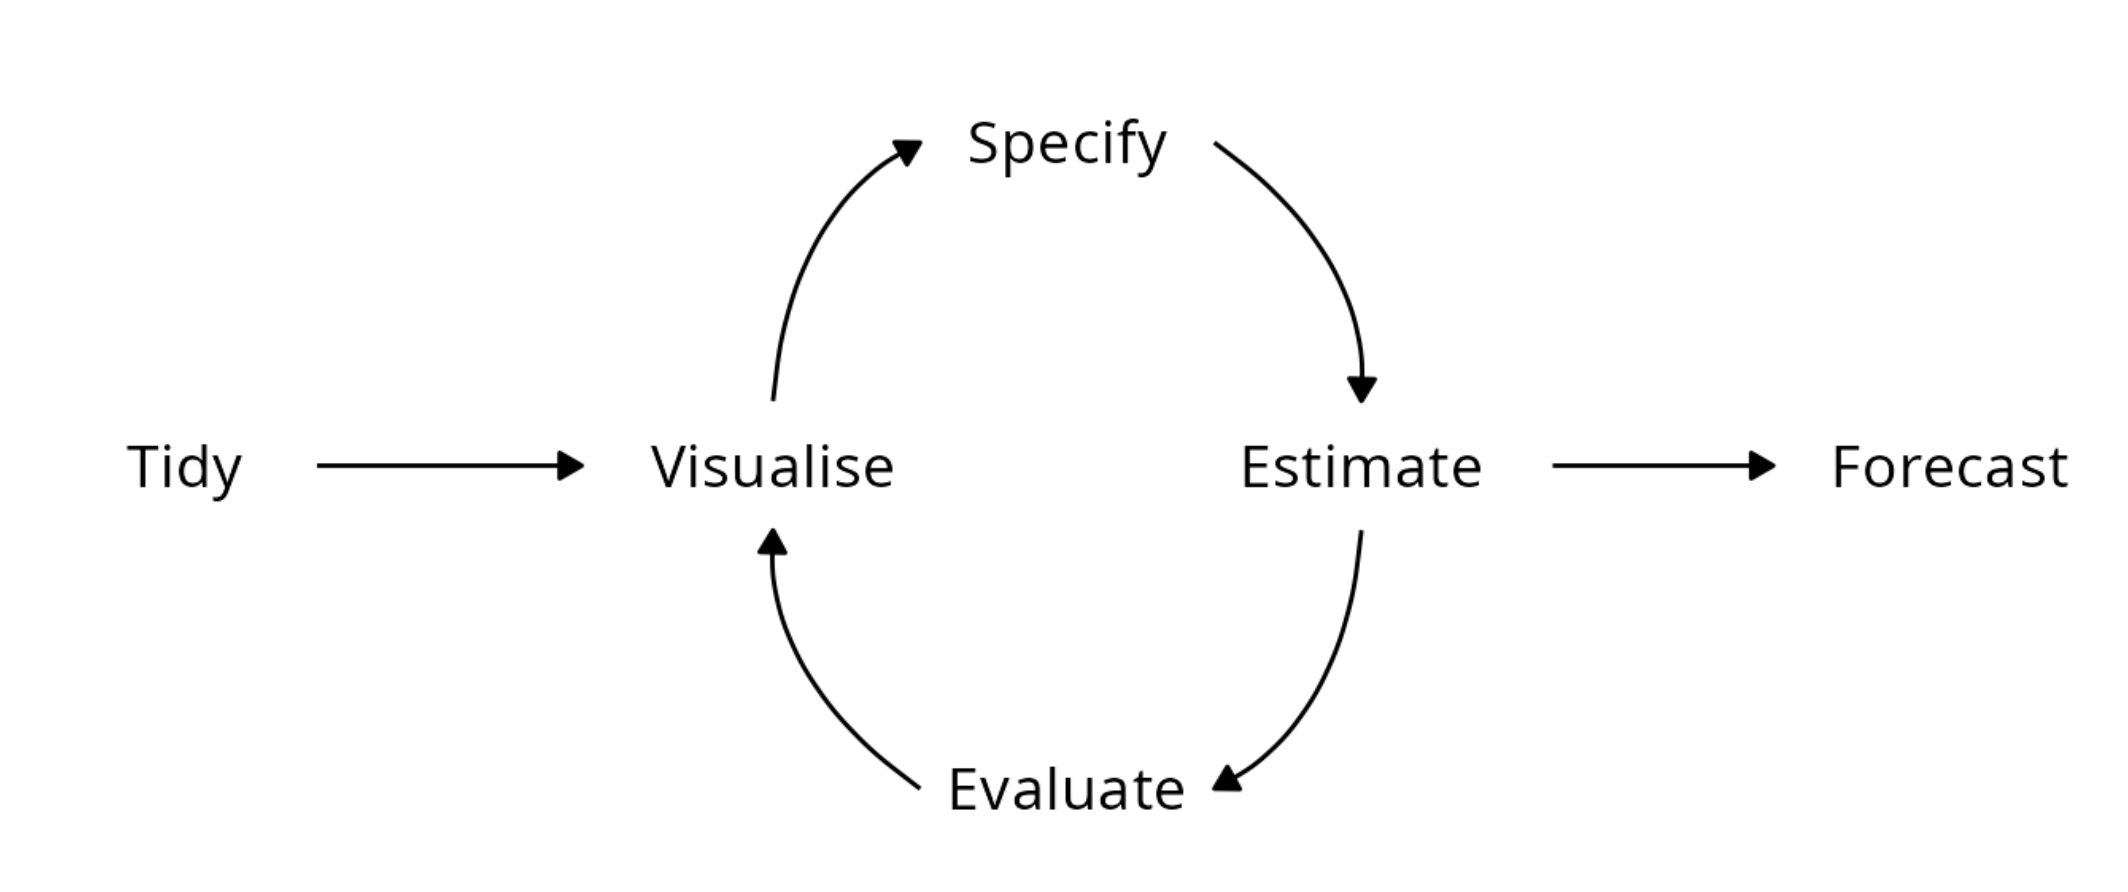


To illustrate the process, we will fit linear trend models to national GDP data stored in `global_economy`.



### 1.1 Data preparation (tidy)

The first step in forecasting is to prepare data in the correct format. This process may involve loading in data, identifying missing values, filtering the time series, and other pre-processing tasks. The functionality provided by pandas substantially simplifies this step.

Many models have different data requirements; some require the series to be in time order, others require no missing values. Checking your data is an essential step to understanding its features and should always be done before models are estimated.

We will model GDP per capita over time; so first, we must compute the relevant variable.

In [5]:
gdp_df = (
    pd.read_csv(DATA_DIR / "global_economy.csv", parse_dates=["ds"])
    [["unique_id", "ds", "GDP", "Population"]]
    .assign(
        GDP=lambda x: x["GDP"].interpolate(), # used computing missing values. (nội suy)
        Population=lambda x: x["Population"].interpolate(),
        y=lambda x: x["GDP"] / x["Population"],
    )
)

### 1.2 Plot the data (visualise)
As we have seen in Chapter 2, visualisation is an essential step in understanding the data. Looking at your data allows you to identify common patterns, and subsequently specify an appropriate model.

The data for one country in our example are plotted in Figure 5.2.

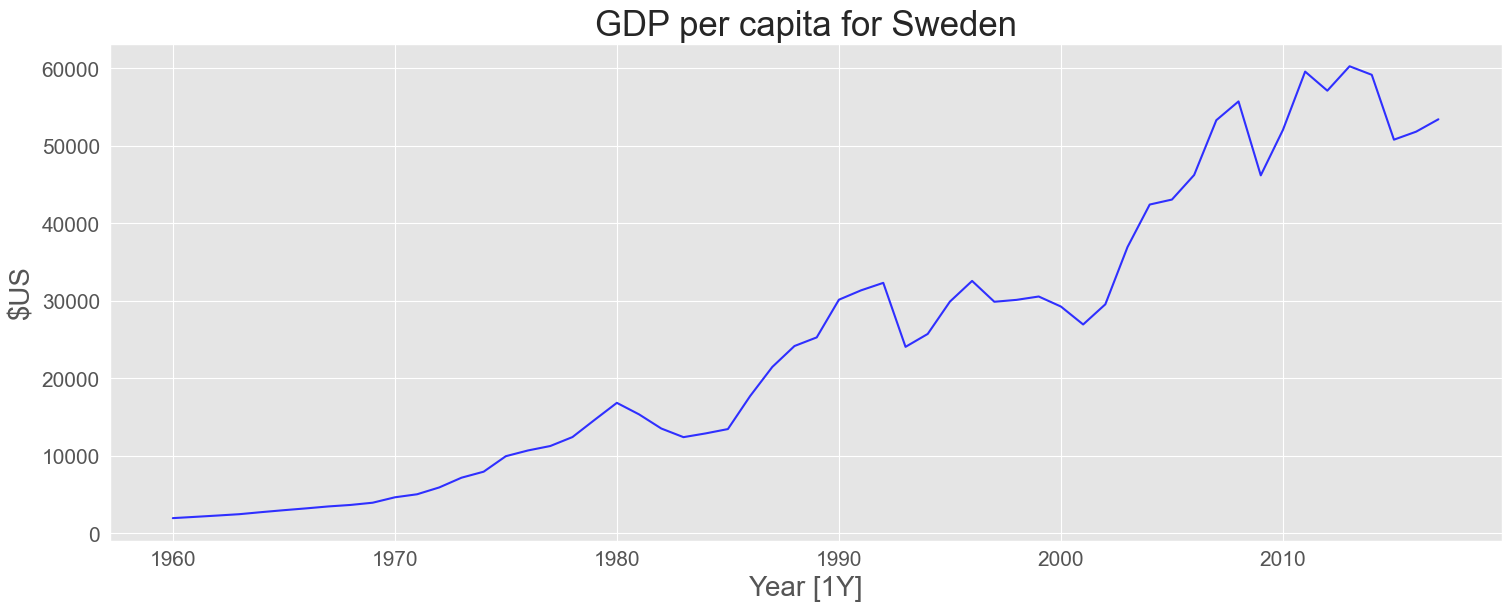

In [6]:
plot_series(gdp_df, ids=["Sweden"],
    xlabel="Year [1Y]", ylabel="$US", title="GDP per capita for Sweden")

### 1.3 Define a model (specify)

There are many different time series models that can be used for forecasting, and much of this book is dedicated to describing various models. Specifying an appropriate model for the data is essential for producing appropriate forecasts.

The StatsForecast package comes with many statistical models already implemented, and it is also possible to use machine learning models from scikit-learn with StatsForecast.

For example, a linear trend model (to be discussed in Chapter 7) for GDP per capita can be specified with the corresponding exogenous variables (as will be specified later) and using the following to specify the models, `SklearnModel(LinearRegression()).`

In this case the model function is LinearRegression() and the response variable is being modelled using a linear trend. We will be taking a closer look at how each model can be specified in their respective sections.

### 1.4 Train the model (estimate)

Once an appropriate model is specified, we next train the model on some data. One or more model specifications can be estimated using a StatsForecast object.

To estimate the model in our example, we first remove the unused columns with.

Then, we fit a linear trend model to the GDP per capita data for each combination of key variables. We create these variables using the pipeline() function where we specify that we want the trend feature. We can then initialise a StatsForecast object that will handle the forecasting process. In this example, it will fit a model to each of the countries in the dataset. The resulting object is an instance of StatsForecast.

In [34]:
sweden_df = (
    gdp_df
    .loc[lambda x: x["unique_id"] == "Sweden"]
    [["unique_id", "ds", "y"]]
)

train_features, valid_features = pipeline(
    sweden_df, features=[trend], freq="Y", h=3)
trend_model = SklearnModel(LinearRegression())
sf = StatsForecast(models=[trend_model], freq="Y")
sf.fit(df=train_features)


,unique_id,ds,trend
0,Sweden,2017-12-31,59.0
1,Sweden,2018-12-31,60.0
2,Sweden,2019-12-31,61.0


### 1.5 Check model performance (evaluate)
Once a model has been fitted, it is important to check how well it has performed on the data. There are several diagnostic tools available to check model behaviour, and also accuracy measures that allow one model to be compared against another. Sections 5.8 and 5.9 go into further details.

### 1.6 Produce forecasts (forecast)
With an appropriate model specified, estimated and checked, it is time to produce the forecasts using the `forecast()` method. The easiest way to use this function is by specifying the number of future observations to forecast. For example, forecasts for the next 10 observations can be generated using `h = 10`.

In other situations, it may be more convenient to provide a dataset of future time periods to forecast. This is commonly required when your model uses additional information from the data, such as exogenous regressors. Additional data required by the model can be included in the dataset of observations to forecast.

In [8]:
fcasts = sf.predict(h=3, X_df=valid_features)

# We are using a LinearRegression wrapper that provides
# the following method for calculating prediction intervals
model = sf.fitted_[0][0].model_["model"]
fcasts = model.add_prediction_intervals(
    fcasts, valid_features.rename(columns={"trend": "x1"}))

This is a forecast table. Each row corresponds to one forecast period for each country. The LinearRegression column contains the point forecast. The point forecast is the mean (or average) of the forecast distribution.

The forecasts can be plotted along with the historical data using `plot_series()` as follows.

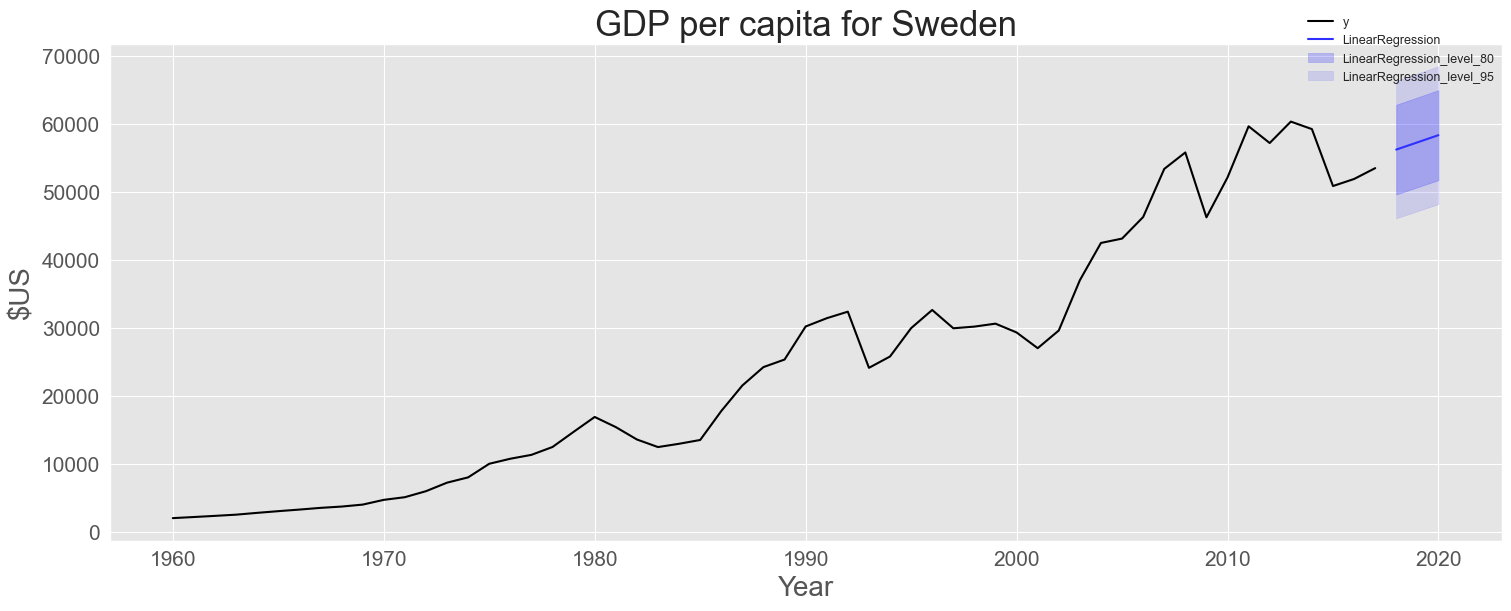

In [9]:
plot_series(sweden_df, fcasts, ids=["Sweden"], level=[80, 95],
    xlabel="Year", ylabel="$US", title="GDP per capita for Sweden",
    palette="black_and_blue", rm_legend=False,
)


## 2. Some simple forecasting methods

In [10]:
production_df = pd.read_csv(DATA_DIR / "aus_production_formatted.csv",
  parse_dates=["ds"])
bricks_df = (
  production_df.loc[lambda x: (
    (x["unique_id"] == "Bricks") & (x["ds"].between("1970", "2004-12"))
  )].dropna()
)

This section introduces four simple but surprisingly effective benchmark forecasting methods. These methods often serve as a baseline to ensure that any new, complex forecasting methods actually provide better results; if they do not outperform these simple alternatives, the new method is not worth considering.

Let $y_1, \dots, y_T$ denote the historical data and $\hat{y}_{T+h|T}$ denote the estimate (forecast) of $y_{T+h}$ based on the data up to time $T$.

#### 1. Mean Method
In this method, the forecasts for all future values are equal to the average (or "mean") of the historical data.
**Formula:**
$$ \hat{y}_{T+h|T} = \bar{y} = \frac{y_{1}+\dots+y_{T}}{T} $$

#### 2. Naïve Method
For naïve forecasts, all future forecasts are simply set to the exact value of the last observation. This method works remarkably well for many economic and financial time series, and because it is optimal when data follow a random walk, these are also referred to as **random walk forecasts**.
**Formula:**
$$ \hat{y}_{T+h|T} = y_{T} $$

#### 3. Seasonal Naïve Method
This method is highly useful for seasonal data. It sets each forecast to be equal to the last observed value from the exact same season (for example, the same month or quarter of the previous year).
**Formula:**
$$ \hat{y}_{T+h|T} = y_{T+h-m(k+1)} $$
**Where:**
* $m$ is the seasonal period.
* $k$ is the integer part of $(h-1)/m$, which represents the number of complete years in the forecast period prior to time $T+h$.

#### 4. Drift Method
A variation of the naïve method, the drift method allows the forecasts to increase or decrease over time. The expected amount of change over time (the **drift**) is set to be the average change seen across the historical data. This is equivalent to drawing a straight line between the first and last observations and extrapolating it into the future.
**Formula:**
$$ \hat{y}_{T+h|T} = y_{T} + \frac{h}{T-1}\sum_{t=2}^T (y_{t}-y_{t-1}) = y_{T} + h \left( \frac{y_{T} -y_{1}}{T-1}\right) $$


> Sometimes one of these simple methods will be the best forecasting method available; but in many cases, these methods will serve as benchmarks rather than the method of choice. That is, any forecasting methods we develop will be compared to these simple methods to ensure that the new method is better than these simple alternatives. If not, the new method is not worth considering.

In [15]:
avg_method = HistoricAverage()
sf = StatsForecast(models=[avg_method], freq="Q")

StatsForecast(models=[HistoricAverage])

In [13]:
naive_method = Naive()
sf = StatsForecast(models=[naive_method], freq="Q")

In [ ]:
# Make sure to specify the seasonal length when initialising the SeasonalNaive class. Since the data is quarterly, the period is 4.
seasonal_naive_method = SeasonalNaive(4)
sf = StatsForecast(models=[seasonal_naive_method], freq="Q")

In [17]:
drift_method = RandomWalkWithDrift()
sf = StatsForecast(models=[drift_method], freq="Q")

#### Example: Australian quarterly beer production

Figure 5.8 shows the first three methods applied to Australian quarterly beer production from 1992 to 2006, with the forecasts compared against actual values in the next 3.5 years. In this case, only the Seasonal Naïve forecasts are close to the observed values from 2007 onwards.

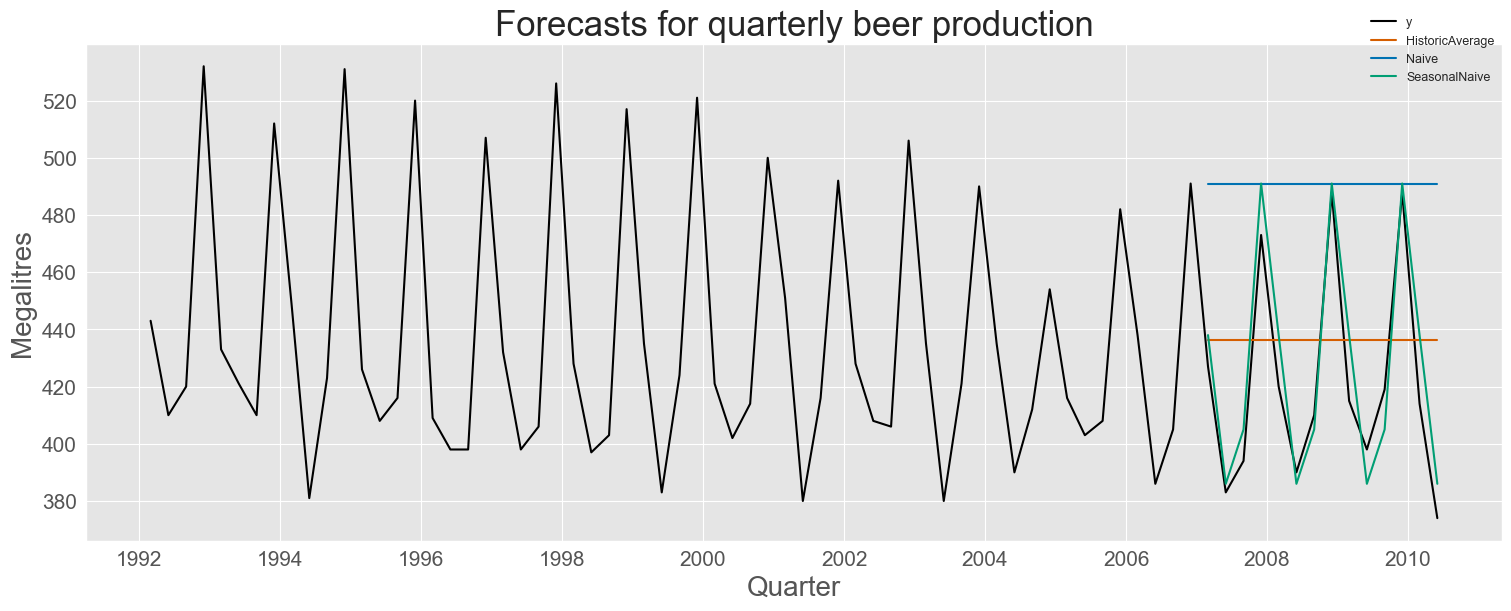

In [21]:
beers_df = production_df.loc[
    lambda x: (x["unique_id"] == "Beer") & (x["ds"] >= "1992")
]
train = beers_df.loc[lambda x: x["ds"] < "2007"]
test = beers_df.loc[lambda x: x["ds"] >= "2007"]
avg_method = HistoricAverage()
naive_method = Naive()
seasonal_naive_method = SeasonalNaive(4)
sf = StatsForecast(
    models=[avg_method, naive_method, seasonal_naive_method],
    freq=pd.offsets.QuarterBegin(1),
)
sf.fit(train)
fcasts = sf.predict(h=14).assign(y=test["y"].to_numpy())
plot_series(train, fcasts,
    xlabel="Quarter", ylabel="Megalitres",
    title="Forecasts for quarterly beer production",
    palette="black_and_3color", rm_legend=False)

#### Example: Google’s daily closing stock price

In Figure 5.9, the non-seasonal methods are applied to Google’s daily closing stock price in 2015, and used to forecast one month ahead. Because stock prices are not observed every day, we first set up a new time index based on the trading days rather than calendar days.

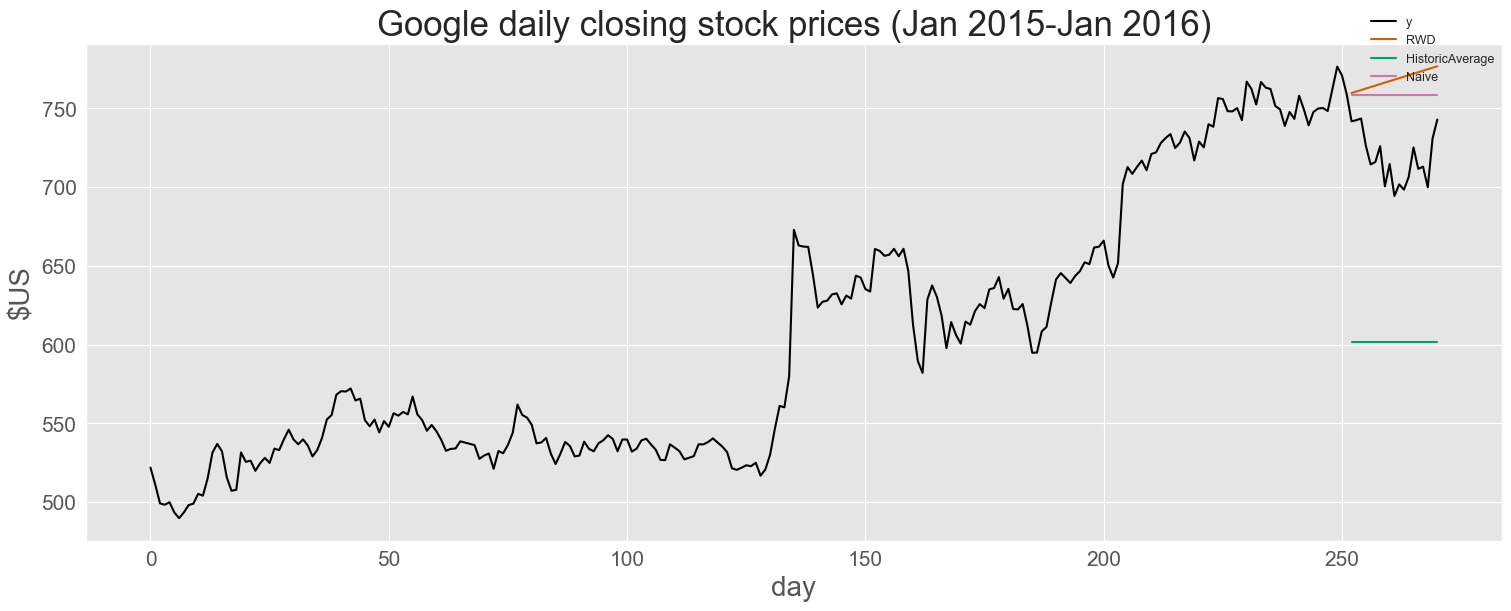

In [24]:
plt.rcParams["figure.figsize"] = (7, 4)
goog_df = (
  pd.read_csv(DATA_DIR / "gafa_stock.csv", parse_dates=["ds"])
  .loc[lambda x: (
    (x["unique_id"] == "GOOG_Close") & x["ds"].between("2015", "2016-01-31")
  )]
)
train = goog_df.loc[lambda x: x["ds"].dt.year == 2015].copy()
test = goog_df.loc[lambda x: x["ds"].dt.year == 2016].copy()

# Re-index based on trading days
train["ds"] = np.arange(len(train))
test["ds"] = len(train) + np.arange(len(test))

avg_method = HistoricAverage()
naive_method = Naive()
drift_method = RandomWalkWithDrift()
sf = StatsForecast(freq=1,
    models=[drift_method, avg_method, naive_method])
sf.fit(train)

fcasts = sf.predict(h=len(test)).assign(y=test["y"].to_numpy())
plot_series(train, fcasts,
    xlabel="day", ylabel="$US",
    title="Google daily closing stock prices (Jan 2015-Jan 2016)",
    palette="black_and_4color", rm_legend=False)

### 5.3 Fitted values and residuals

Section 5.3 defines the core components of what is "left over" after a time series model makes its predictions on the historical data.

#### Fitted Values
Each observation in a time series can be forecast using all previous observations, which are referred to as **fitted values**. They almost always involve one-step forecasts. 
**Notation:** 
They are denoted by $\hat{y}_{t|t-1}$, meaning the forecast of $y_t$ based on observations $y_1, \dots, y_{t-1}$. This is often abbreviated to just $\hat{y}_t$.

Actually, fitted values are often not true forecasts because any parameters involved in the forecasting method are estimated using all available observations in the time series, including future observations. On the other hand, Naïve or Seasonal Naïve forecasts do not involve any parameters, and so fitted values are true forecasts in such cases.

#### Residuals
The **residuals** in a time series model are what is left over after fitting a model. They are the exact difference between the actual observed values and the model's fitted values.
**Formula:**
$$ e_{t} = y_{t} - \hat{y}_{t} $$

#### Innovation Residuals
If a mathematical transformation (like a logarithm) has been applied to the data before modeling, it is useful to look at the residuals on that transformed scale. These are called **innovation residuals**. For example, if the model predicts the logarithm of the data ($w_t = \log(y_t)$), the innovation residual is $w_t - \hat{w}_t$. If no transformation was used, innovation residuals are identical to regular residuals.

The fitted values can be obtained using the `forecast_fitted_values()` function after running `forecast()` specifying `fitted=True`. We then store those values in fitted column, and then we can compute the residuals by taking the difference between the `y` column and the `fitted` column.

In [25]:
train = beers_df.loc[lambda x: x["ds"] < "2007"]
test = beers_df.loc[lambda x: x["ds"] >= "2007"]

avg_method = HistoricAverage()
sf = StatsForecast(models=[avg_method], freq="Q")
sf.forecast(h=14, df=train, fitted=True)
fitted_values = sf.forecast_fitted_values()
df = train.assign(
    fitted=fitted_values["HistoricAverage"].to_numpy(),
    resid=lambda x: x["y"] - x["fitted"],
    innov=lambda x: x["y"] - x["fitted"],
)
df.head()

,unique_id,ds,y,fitted,resid,innov
144,Beer,1992-03-01,443.0,436.45,6.55,6.55
145,Beer,1992-06-01,410.0,436.45,-26.45,-26.45
146,Beer,1992-09-01,420.0,436.45,-16.45,-16.45
147,Beer,1992-12-01,532.0,436.45,95.55,95.55
148,Beer,1993-03-01,433.0,436.45,-3.45,-3.45


> Residuals are useful in checking whether a model has adequately captured the information in the data. For this purpose, we use innovation residuals.

> If patterns are observable in the innovation residuals, the model can probably be improved. We will look at some tools for exploring patterns in residuals in the next section.

### 5.4 Residual diagnostics

Section 5.4 explains how to check whether a forecasting method has adequately utilized all the available information in the data by analyzing its innovation residuals. 

#### Properties of Good Residuals
A good forecasting method will yield innovation residuals with two essential properties:
1. **Uncorrelated:** If there are correlations between residuals, there is still information left in the residuals that should be used in computing forecasts.
2. **Zero Mean:** If they have a mean other than zero, the forecasts are biased. (This can be easily fixed by adding the mean $m$ to all forecasts).

It is also useful (though not strictly necessary) for residuals to have two additional properties:
1. **Constant variance** (also known as homoscedasticity).
2. **Normally distributed**.
*Note: These two properties make calculating prediction intervals much easier, but failing them doesn't necessarily mean the forecast method can be improved.*

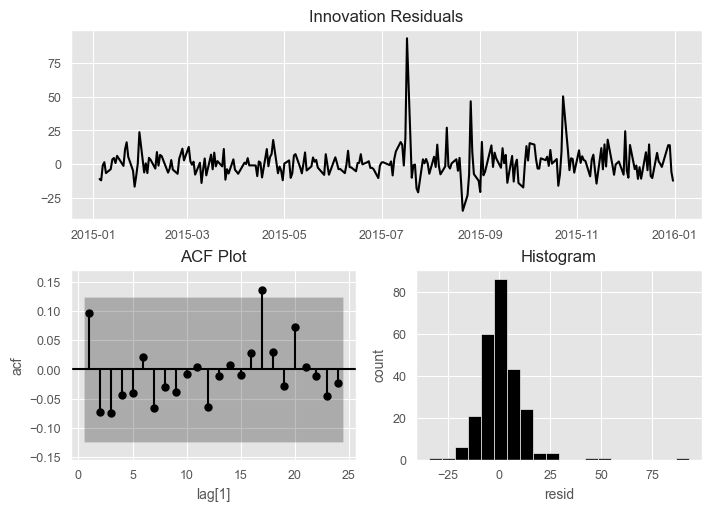

In [30]:
# Example: Forecasting Google daily closing stock prices

def plot_diagnostics(data):
    _, axes = plt.subplot_mosaic([["resid", "resid"], ["acf", "hist"]])
    ax = axes["resid"]
    ax.plot(data["ds"], data["resid"])
    ax.set(title="Innovation Residuals")
    ax = axes["acf"]
    plot_acf(data["resid"].dropna(),
        zero=False, bartlett_confint=False, auto_ylims=True, ax=ax)
    ax.set(title="ACF Plot", xlabel="lag[1]", ylabel="acf")
    ax = axes["hist"]
    ax.hist(data["resid"], bins=20)
    ax.set(title="Histogram", xlabel="resid", ylabel="count")

plt.rcParams["figure.figsize"] = (7, 5)
plot_diagnostics(resid)

 show that the Naïve method produces forecasts that appear to account for all available information. The mean of the residuals is close to zero and there is no significant correlation in the residuals series. The time plot of the residuals shows that the variation of the residuals stays much the same across the historical data, apart from the one outlier, and therefore the residual variance can be treated as constant. This can also be seen on the histogram of the residuals. The histogram suggests that the residuals may not be normal — the right tail seems a little too long, even when we ignore the outlier. Consequently, forecasts from this method will probably be quite good, but prediction intervals that are computed assuming a normal distribution may be inaccurate.

#### Portmanteau Tests for Autocorrelation
Instead of looking at a single lag's autocorrelation (which might yield a false positive due to multiple hypothesis testing), we can formally test a whole group of autocorrelations simultaneously to see if they are significantly different from a white noise process. This is called a **portmanteau test**.

**1. Box-Pierce Test**
This test is based on the sum of squared autocorrelations.
**Formula:**
$$ Q = T \sum_{k=1}^\ell r_k^2 $$
**Where:**
* $T$ is the number of observations.
* $\ell$ is the maximum lag being considered (suggested $\ell=10$ for non-seasonal and $\ell=2m$ for seasonal data).
* $r_k$ is the autocorrelation for lag $k$.

**2. Ljung-Box Test**
This is a related, more accurate test for autocorrelation. 
**Formula:**
$$ Q^* = T(T+2) \sum_{k=1}^\ell (T-k)^{-1}r_k^2 $$

*Interpretation:* For both tests, large values of $Q$ or $Q^*$ suggest that the autocorrelations do not come from a white noise series. If the series is white noise, both statistics will follow a $\chi^2$ distribution with $\ell$ degrees of freedom.

In [31]:
resid_test = acorr_ljungbox(resid["resid"].dropna(), boxpierce=True)
resid_test

,lb_stat,lb_pvalue,bp_stat,bp_pvalue
1,2.417,0.120,2.389,0.122
2,3.761,0.153,3.711,0.156
3,5.193,0.158,5.115,0.164
4,5.675,0.225,5.585,0.232
5,6.084,0.298,5.983,0.308
6,6.195,0.402,6.090,0.413
7,7.303,0.398,7.159,0.413
8,7.525,0.481,7.372,0.497
9,7.902,0.544,7.733,0.561
10,7.914,0.637,7.745,0.654


For both $Q$ and $Q*$, the results are not significant (i.e., the p-values are relatively large). Thus, we can conclude that the residuals are not distinguishable from a white noise series.

An alternative simple approach that may be appropriate for forecasting the Google daily closing stock price is the drift method. The `RandomWalkWithDrift()` function is used, and we also return the fitted values to analyse the residuals.

In [32]:
drift_method = RandomWalkWithDrift()
sf = StatsForecast(models=[drift_method], freq="B")
sf.fit(train)
fcasts = sf.forecast(h=10, df=train, fitted=True)
insample = sf.forecast_fitted_values().assign(
    resid=lambda x: x["y"] - x["RWD"]
)
insample.head()

resid_test = acorr_ljungbox(insample["resid"].dropna(), boxpierce=True)
resid_test

,lb_stat,lb_pvalue,bp_stat,bp_pvalue
1,2.417,0.120,2.389,0.122
2,3.761,0.153,3.711,0.156
3,5.193,0.158,5.115,0.164
4,5.675,0.225,5.585,0.232
5,6.084,0.298,5.983,0.308
6,6.195,0.402,6.090,0.413
7,7.303,0.398,7.159,0.413
8,7.525,0.481,7.372,0.497
9,7.902,0.544,7.733,0.561
10,7.914,0.637,7.745,0.654


As with the Naïve method, the residuals from the drift method are indistinguishable from a white noise series.

If p-value $< 0.05$: You reject the null hypothesis (meaning the residuals are not white noise).

If p-value $> 0.05$: You fail to reject the null hypothesis (meaning there is no evidence to suggest the residuals are anything other than white noise).

x`